# Bài Toán VQA-E (Visual Question Answering with Explanations)
## Mô hình Baseline: Pretrained CNN + BiLSTM (Không dùng Attention)

---
### Bước 1: Cài đặt các thư viện lõi
Đầu tiên, chúng ta cần cài đặt các thư viện nền tảng với phiên bản cụ thể để đảm bảo tính tương thích:
- `torch`, `torchvision`: Dành cho việc xây dựng và huấn luyện mô hình Deep Learning.
- `torchtext`: Hỗ trợ đắc lực trong việc xử lý văn bản và xây dựng từ điển (Vocabulary).
- `spacy`: Thư viện xử lý ngôn ngữ tự nhiên (NLP) mạnh mẽ, được dùng để chia từ (tokenization) tiếng Anh một cách chuẩn xác.

In [1]:
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17

### Bước 2: Khai báo thư viện và Thiết lập hệ thống
- **Import các module cần thiết:** Nạp các thư viện toán học (`numpy`), xử lý ảnh (`PIL`, `timm`), trực quan hóa (`matplotlib`), và công cụ tải dữ liệu của PyTorch (`DataLoader`).
- **Khởi tạo Spacy:** Load bộ ngữ pháp tiếng Anh `en_core_web_sm` dùng để chia cắt câu hỏi và câu giải thích thành các từ đơn lẻ.
- **Cố định Seed (Reproducibility):** Hàm `set_seed(59)` giúp loại bỏ sự ngẫu nhiên. Khi cùng một seed, mọi lần chạy (chia batch, khởi tạo trọng số, ...) đều sẽ cho ra kết quả giống nhau, thuận tiện cho việc debug.
- **Kích hoạt GPU:** Kiểm tra và ưu tiên sử dụng thiết bị `cuda` (GPU) nếu có để tăng tốc độ huấn luyện gấp hàng chục lần so với `cpu`.

In [2]:
import torchtext
torchtext.disable_torchtext_deprecation_warning()
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
import random
import json
import numpy as np
import spacy
import shutil
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchtext.vocab import build_vocab_from_iterator
from tqdm.auto import tqdm

# Khởi tạo spacy
try:
    eng = spacy.load("en_core_web_sm")
except:
    os.system("python -m spacy download en_core_web_sm")
    eng = spacy.load("en_core_web_sm")

def set_seed(seed=59):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


### Bước 3: Tải dữ liệu ảnh (MS COCO Val 2014)
Bài toán VQA-E sử dụng chung nguồn ảnh với bộ dữ liệu MS COCO. Việc tải file trực tiếp về ổ cứng thể rắn ảo (`/content/`) của Google Colab bằng lệnh `wget` và `unzip` sẽ giúp:
- **Tối ưu tốc độ:** Đọc ảnh từ Colab cực kỳ nhanh so với việc load ảnh qua mạng từ Google Drive.
- **Lưu ý:** Thao tác này tải khoảng 6GB dữ liệu, nên sẽ mất một vài phút. Sau khi chạy xong, bạn nhớ upload file JSON (`VQA-E_val_set.json`) vào thư mục `/content/VQA_E/Annotations/`.

In [3]:
# Tạo thư mục
os.makedirs('/content/VQA_E/Images', exist_ok=True)
os.makedirs('/content/VQA_E/Annotations', exist_ok=True)

print("1. Đang tải Ảnh COCO Val 2014 (~6GB)...")
!wget -c -q http://images.cocodataset.org/zips/val2014.zip -P /content/VQA_E/Images/

print("2. Đang giải nén dữ liệu...")
!unzip -q -n /content/VQA_E/Images/val2014.zip -d /content/VQA_E/Images/

print("Hoàn tất tải và giải nén!")
# LƯU Ý: Vui lòng upload thủ công file VQA-E_val_set.json của bạn vào đường dẫn /content/VQA_E/Annotations/

1. Đang tải Ảnh COCO Val 2014 (~6GB)...
2. Đang giải nén dữ liệu...
Hoàn tất tải và giải nén!


### Bước 4: Khai phá và Đồng bộ dữ liệu (Data Parsing)
Hàm `load_vqa_e_data` thực hiện các nhiệm vụ:
1. Đọc file `VQA-E_val_set.json`.
2. Ghép nối `img_id` với tên file ảnh thực tế trên ổ đĩa. Nếu file ảnh tồn tại, nó sẽ lưu lại bộ 3 thông tin quan trọng nhất vào danh sách (List): Đường dẫn ảnh (`image_path`), Câu hỏi (`question`) và Câu giải thích đầu tiên (`explanation`).
3. Dữ liệu sau đó được **xáo trộn ngẫu nhiên** và chia thành 2 tập độc lập:
   - **Tập Train (80%):** Dùng để dạy cho mô hình học.
   - **Tập Val (20%):** Dùng làm bài thi để đánh giá năng lực thực sự của mô hình sau mỗi Epoch.
Cuối cùng, hàm `show_random_samples` sẽ in thử một vài bức ảnh cùng câu hỏi và đáp án chuẩn (Ground Truth) ra màn hình để ta kiểm tra xem dữ liệu đã khớp nhau chưa.

Đang đọc file JSON VQA-E...


Đang xử lý dữ liệu:   0%|          | 0/88488 [00:00<?, ?it/s]

Số lượng Train: 12000 | Val: 3000
ĐANG TRÍCH XUẤT DỮ LIỆU ĐỂ XEM THỬ...


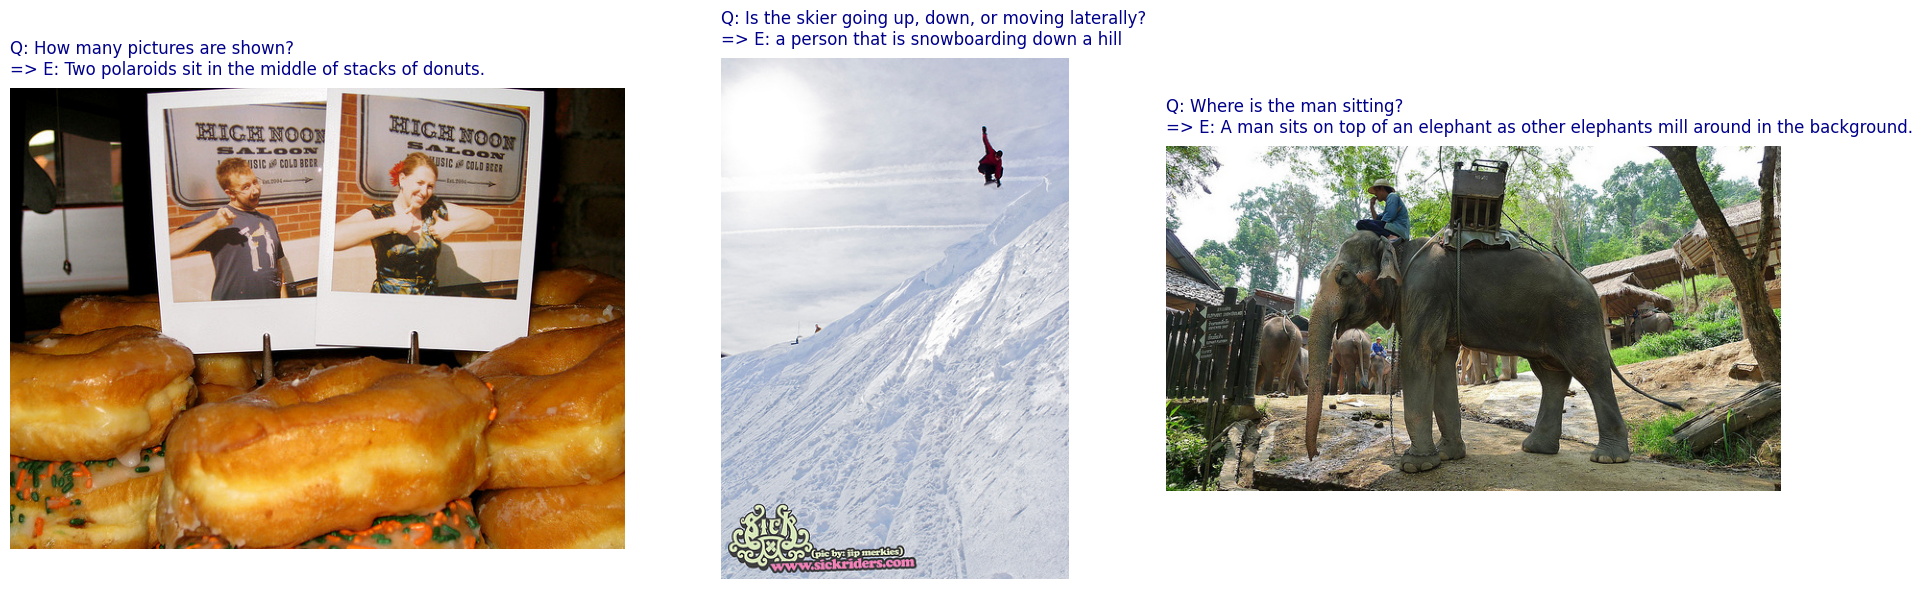

In [4]:
def load_vqa_e_data(json_path, img_dir, max_samples=15000):
    print("Đang đọc file JSON VQA-E...")
    with open(json_path, 'r') as f:
        data = json.load(f)

    dataset = []
    for item in tqdm(data, desc="Đang xử lý dữ liệu"):
        img_id = item['img_id']
        img_filename = f"COCO_val2014_{img_id:012d}.jpg"

        dataset.append({
            'image_path': os.path.join("val2014", img_filename),
            'question': item['question'],
            'explanation': item['explanation'][0] # Lấy câu giải thích đầu tiên
        })

    random.shuffle(dataset)
    if max_samples: dataset = dataset[:max_samples]
    return dataset

JSON_PATH = '/content/VQA_E/Annotations/VQA-E_val_set.json'
IMG_DIR = '/content/VQA_E/Images'

# Cần file JSON để chạy các phần dưới
if os.path.exists(JSON_PATH):
    all_data = load_vqa_e_data(JSON_PATH, IMG_DIR, max_samples=15000)

    # Chia Train / Val theo tỉ lệ 80/20
    split_idx = int(len(all_data) * 0.8)
    train_data = all_data[:split_idx]
    val_data = all_data[split_idx:]
    print(f"Số lượng Train: {len(train_data)} | Val: {len(val_data)}")
else:
    print(f"LỖI: Chưa tìm thấy file {JSON_PATH}. Bạn vui lòng upload file JSON để tiếp tục.")
    train_data, val_data = [], []

def show_random_samples(data_list, img_dir, num_samples=3):
    if not data_list: return
    samples = random.sample(data_list, min(num_samples, len(data_list)))
    fig, axes = plt.subplots(1, len(samples), figsize=(18, 6))
    if num_samples == 1: axes = [axes]

    for i, sample in enumerate(samples):
        img_path = os.path.join(img_dir, sample['image_path'])

        try:
            img = Image.open(img_path).convert('RGB')
            axes[i].imshow(img)
        except Exception as e:
            axes[i].text(0.5, 0.5, 'Lỗi đọc ảnh', ha='center')

        axes[i].axis('off')
        title = f"Q: {sample['question']}\n=> E: {sample['explanation']}"
        axes[i].set_title(title, fontsize=12, color='darkblue', pad=10, loc='left')

    plt.tight_layout()
    plt.show()

print("ĐANG TRÍCH XUẤT DỮ LIỆU ĐỂ XEM THỬ...")
show_random_samples(train_data, IMG_DIR, num_samples=3)

### Bước 5: Xây dựng Từ điển (Vocabulary) & Pipeline Dữ liệu



Phần này là khâu xử lý dữ liệu đầu vào cực kỳ quan trọng cho mô hình Sequence-to-Sequence (Seq2Seq):
1. **Build Vocab:** - Duyệt qua toàn bộ văn bản trong tập Train để gom các từ vựng xuất hiện từ 2 lần trở lên.
   - Định nghĩa 4 mã đặc biệt (Special Tokens):
     * `<pad>`: Từ đệm (để ép các câu có độ dài bằng nhau).
     * `<sos>`: Start-of-Sequence (Đánh dấu bắt đầu câu giải thích).
     * `<eos>`: End-of-Sequence (Đánh dấu kết thúc câu giải thích).
     * `<unk>`: Unknown (Dùng thay thế các từ lạ không có trong từ điển).
2. **Class `VQAEDataset`:** Lớp này thực hiện 3 việc cho từng sample:
   - Load và chuẩn hóa ảnh kích thước `224x224` (chuẩn đầu vào của ResNet).
   - Biến câu hỏi thành chuỗi số (ID của từ) và đệm `<pad>`.
   - Biến câu giải thích thành chuỗi số, kẹp giữa thẻ `<sos>` ở đầu và `<eos>` ở cuối.
3. **Dataloader:** Đóng gói Dataset thành các lô (Batch) có kích thước 64 để đưa vào GPU huấn luyện song song.

In [5]:
# 1. Xây dựng Vocab
def yield_tokens(data_iter):
    for sample in data_iter:
        yield [token.text.lower() for token in eng.tokenizer(sample['question'])]
        yield [token.text.lower() for token in eng.tokenizer(sample['explanation'])]

PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
special_symbols = ['<pad>', '<sos>', '<eos>', '<unk>']

print("Đang xây dựng bộ từ vựng...")
if train_data:
    vocab = build_vocab_from_iterator(
        yield_tokens(train_data), min_freq=2, specials=special_symbols, special_first=True
    )
    vocab.set_default_index(UNK_IDX)
    print(f"Kích thước bộ từ vựng: {len(vocab)} từ")
else: vocab = None

# 2. Định nghĩa Dataset
class VQAEDataset(Dataset):
    def __init__(self, data, vocab, max_len=20, transform=None, img_dir=''):
        self.data = data
        self.vocab = vocab
        self.max_len = max_len
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self): return len(self.data)

    def __getitem__(self, index):
        sample = self.data[index]
        img_path = os.path.join(self.img_dir, sample['image_path'])
        img = self.transform(Image.open(img_path).convert('RGB')) if self.transform else Image.open(img_path).convert('RGB')

        q_tokens = [token.text.lower() for token in eng.tokenizer(sample['question'])]
        q_indices = [self.vocab[t] for t in q_tokens][:self.max_len]
        q_indices += [self.vocab['<pad>']] * (self.max_len - len(q_indices))

        # Giải thích: Bọc bằng <sos> và <eos>
        e_tokens = [token.text.lower() for token in eng.tokenizer(sample['explanation'])]
        e_indices = [self.vocab['<sos>']] + [self.vocab[t] for t in e_tokens] + [self.vocab['<eos>']]
        e_indices = e_indices[:self.max_len]
        e_indices += [self.vocab['<pad>']] * (self.max_len - len(e_indices))

        return img, torch.tensor(q_indices, dtype=torch.long), torch.tensor(e_indices, dtype=torch.long)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

if train_data:
    train_dataset = VQAEDataset(train_data, vocab, max_len=20, transform=transform, img_dir=IMG_DIR)
    val_dataset = VQAEDataset(val_data, vocab, max_len=20, transform=transform, img_dir=IMG_DIR)

    # Batch size đổi thành 64 để phù hợp với ResNet18 + Attention
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

Đang xây dựng bộ từ vựng...
Kích thước bộ từ vựng: 3560 từ


### Bước 6: Định nghĩa Kiến trúc Seq2Seq (Encoder - Decoder Không Attention)



**1. Khai báo Class `VQAE_NoAttention`:**
- **Image Encoder:** Dùng mạng `ResNet18` đã train sẵn (Pretrained). Tham số `global_pool='avg'` cực kỳ quan trọng: nó nén toàn bộ ma trận đặc trưng ảnh thành một vector duy nhất `[512]`, đồng nghĩa với việc vứt bỏ thông tin không gian (No Attention).
- **Question Encoder:** Dùng `BiLSTM` (LSTM 2 chiều) để mã hóa câu hỏi, sau đó ghép nối đặc trưng 2 chiều lại thành một vector `[512]`.
- **Fusion (Kết hợp):** Nối ảnh và câu hỏi lại với nhau thành vector độ dài `[1024]`, sau đó đưa qua mạng Linear để nén về Ngữ cảnh (`h_dec` kích thước `[512]`).
- **Decoder:** LSTM nhận Ngữ cảnh này làm trạng thái khởi tạo. Nhờ vòng lặp `for`, mô hình sẽ tự động sinh từng từ dựa theo cơ chế **Scheduled Sampling** (gieo xúc xắc quyết định việc có "mớm" từ chuẩn từ nhãn vào mô hình hay để nó tự bơi).

**2. Hàm Tính Loss & Validation (`evaluate_seq2seq`):**
Hàm này mô phỏng bài kiểm tra cuối kỳ. Chúng ta thiết lập `teacher_forcing_ratio = 0.0` (tắt chế độ mớm bài hoàn toàn) để AI bắt buộc phải "tự lực cánh sinh" sinh ra cả câu giải thích. Nếu AI sai từ nào, nó phải tự nhận hậu quả cho các từ phía sau. Điểm số Val Accuracy ở đây sẽ rất khắt khe nhưng phản ánh 100% sự thật.

In [6]:
class VQAE_NoAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_size=512, drop_p=0.4):
        super(VQAE_NoAttention, self).__init__()

        # 1. ENCODERS
        self.img_encoder = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.q_lstm = nn.LSTM(embed_dim, hidden_size // 2, batch_first=True, bidirectional=True)

        # 2. BỘ KẾT HỢP (CONTEXT)
        self.fc_context = nn.Linear(512 + 512, hidden_size)

        # 3. DECODER
        self.dec_lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(drop_p)

    def forward(self, img, question, explanation_input=None, max_gen_len=20, sos_idx=1, teacher_forcing_ratio=0.5):
        # A. Trích xuất đặc trưng Ảnh [B, 512]
        img_feat = self.img_encoder(img)

        # B. Trích xuất đặc trưng Câu hỏi [B, 512]
        q_emb = self.dropout(self.embedding(question))
        _, (h_n, _) = self.q_lstm(q_emb)
        q_feat = torch.cat((h_n[0], h_n[1]), dim=1)

        # C. Khởi tạo Trạng thái ngữ cảnh (Context Vector)
        combined = torch.cat((img_feat, q_feat), dim=1)
        h_dec = torch.relu(self.fc_context(self.dropout(combined))).unsqueeze(0)
        c_dec = torch.zeros_like(h_dec)

        # D. QUÁ TRÌNH DECODING CHUNG (Scheduled Sampling)
        batch_size = img.size(0)
        device = img.device
        curr_token = torch.full((batch_size, 1), sos_idx, dtype=torch.long, device=device)
        outputs = []

        # Quyết định độ dài vòng lặp
        gen_len = explanation_input.size(1) if explanation_input is not None else max_gen_len

        for t in range(gen_len):
            emb = self.dropout(self.embedding(curr_token))
            out, (h_dec, c_dec) = self.dec_lstm(emb, (h_dec, c_dec))
            vocab_logits = self.fc_out(out)
            outputs.append(vocab_logits)

            # Lấy từ có xác suất cao nhất tại bước t
            top1 = vocab_logits.argmax(dim=-1)

            # Cơ chế Scheduled Sampling: Gieo xúc xắc mớm bài
            if explanation_input is not None and random.random() < teacher_forcing_ratio:
                # Lấy token thật của bước tiếp theo (t+1) để mớm bài
                if t + 1 < gen_len:
                    curr_token = explanation_input[:, t+1:t+2]
            else:
                curr_token = top1 # Tự bơi (lấy từ vừa đoán)

        logits = torch.cat(outputs, dim=1)
        return logits

def evaluate_seq2seq(model, dataloader, criterion, device, vocab):
    model.eval()
    total_loss, correct_tokens, total_tokens = 0, 0, 0
    pad_idx = vocab['<pad>']
    sos_idx = vocab['<sos>']

    with torch.no_grad():
        for imgs, questions, explanations in tqdm(dataloader, desc="Validating", leave=False):
            imgs, questions, explanations = imgs.to(device), questions.to(device), explanations.to(device)

            exp_target = explanations[:, 1:]
            max_len = exp_target.shape[1]

            # NGẮT HOÀN TOÀN MỚM BÀI: teacher_forcing_ratio=0.0
            logits = model(imgs, questions, explanation_input=None, max_gen_len=max_len, sos_idx=sos_idx, teacher_forcing_ratio=0.0)

            loss = criterion(logits.reshape(-1, logits.size(-1)), exp_target.reshape(-1))
            total_loss += loss.item()

            preds = logits.argmax(dim=-1)
            mask = exp_target != pad_idx
            correct_tokens += ((preds == exp_target) & mask).sum().item()
            total_tokens += mask.sum().item()

    return total_loss / len(dataloader), correct_tokens / total_tokens if total_tokens > 0 else 0

def fit_seq2seq(model, train_loader, val_loader, optimizer, epochs, device, vocab):
    criterion = nn.CrossEntropyLoss(ignore_index=vocab['<pad>'])
    master_bar = tqdm(range(epochs), desc="Tổng tiến trình")
    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in master_bar:
        model.train()
        train_loss = 0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=True)

        for imgs, questions, explanations in progress_bar:
            imgs, questions, explanations = imgs.to(device), questions.to(device), explanations.to(device)

            exp_input, exp_target = explanations[:, :-1], explanations[:, 1:]

            optimizer.zero_grad()
            # BẬT MỚM BÀI 50%: teacher_forcing_ratio=0.5
            logits = model(imgs, questions, explanation_input=exp_input, teacher_forcing_ratio=0.5)
            loss = criterion(logits.reshape(-1, logits.size(-1)), exp_target.reshape(-1))

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss, val_acc = evaluate_seq2seq(model, val_loader, criterion, device, vocab)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc * 100)

        tqdm.write(f'EPOCH {epoch + 1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')

    return train_losses, val_losses, val_accuracies

# Khởi tạo mô hình
if vocab:
    model = VQAE_NoAttention(vocab_size=len(vocab)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

### Bước 7: Khởi động Quá trình Huấn luyện (Training Loop)
Tại đây, chúng ta gọi hàm `fit_seq2seq` và thiết lập vòng lặp chạy trong `15 Epochs`.
Trong pha Train, chúng ta sử dụng `teacher_forcing_ratio=0.5`. Nghĩa là: 50% thời gian mô hình sẽ được cung cấp từ khóa chuẩn ở bước phía trước để dự đoán từ tiếp theo (giúp nó định hướng nhanh), và 50% thời gian nó phải dùng chính từ sai do mình vừa tạo ra (giúp nó rèn sức đề kháng với lỗi - giải quyết vấn đề **Exposure Bias**).

*Cứ sau mỗi Epoch, mô hình sẽ được mang ra làm bài kiểm tra trên tập Validation để lưu lại Loss và Accuracy.*

In [7]:
if vocab:
    train_losses, val_losses, val_accuracies = fit_seq2seq(model, train_loader, val_loader, optimizer, epochs=15, device=device, vocab=vocab)

Tổng tiến trình:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15:   0%|          | 0/188 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

EPOCH 01/15 | Train Loss: 5.7683 | Val Loss: 4.8674 | Val Acc: 17.63%


Epoch 2/15:   0%|          | 0/188 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

EPOCH 14/15 | Train Loss: 3.9754 | Val Loss: 4.5623 | Val Acc: 18.27%


Epoch 15/15:   0%|          | 0/188 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

EPOCH 15/15 | Train Loss: 3.9333 | Val Loss: 4.5473 | Val Acc: 17.77%


### Bước 8: Đánh giá Lịch sử Huấn luyện (Learning Curves)
- **Biểu đồ bên trái (Loss):** Thể hiện xu hướng độ tự tin của mô hình. Nếu Train Loss giảm nhưng Val Loss đi ngang hoặc tăng lên, tức là mô hình bắt đầu có dấu hiệu Overfitting (học vẹt).
- **Biểu đồ bên phải (Accuracy):** Thể hiện tỉ lệ sinh từ chính xác. Do không có Attention, việc bắt AI phải thuộc được mối liên hệ giữa các phần của ảnh và câu trả lời dài là cực kỳ khó khăn, vì vậy Val Accuracy thường sẽ thấp hơn phiên bản Attention rất nhiều và dễ dậm chân tại chỗ.

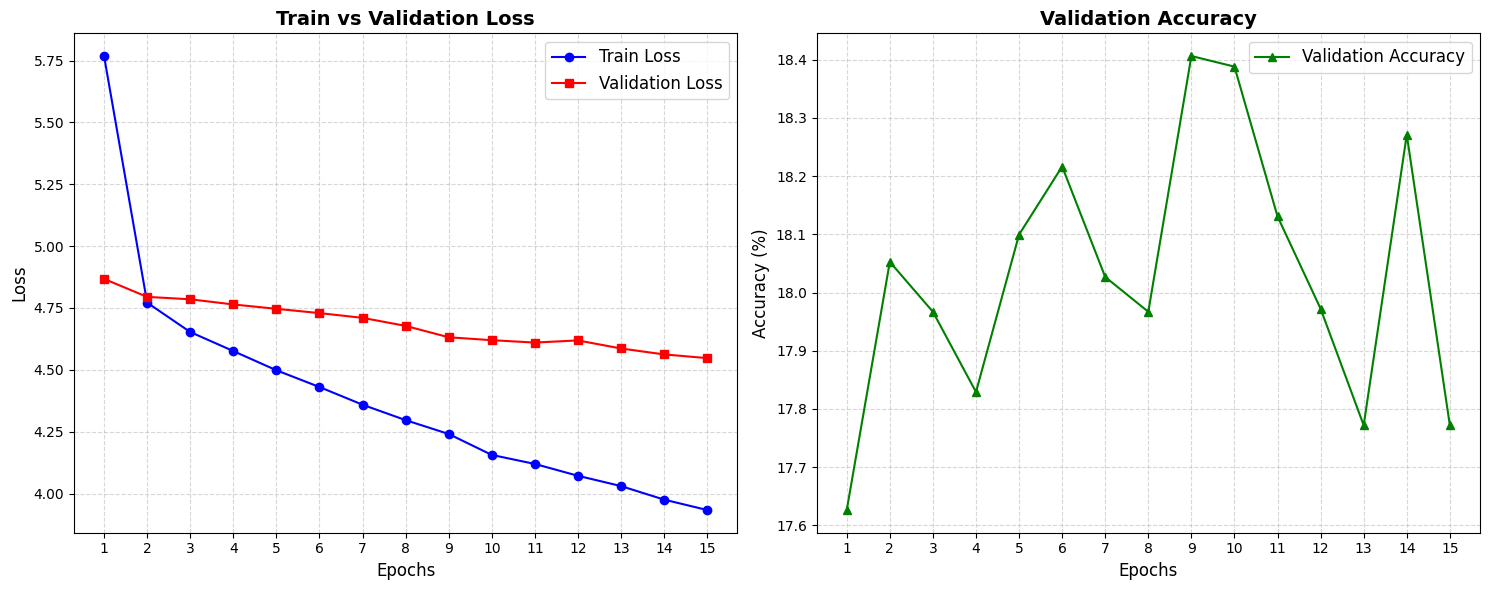

In [8]:
if vocab:
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'b-', label='Train Loss', marker='o')
    plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', marker='s')
    plt.title('Train vs Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(epochs_range)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, val_accuracies, 'g-', label='Validation Accuracy', marker='^')
    plt.title('Validation Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xticks(epochs_range)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

### Bước 9: Thử nghiệm Thực tế (Inference / Demo)
Hàm `demo_vqae_noattention` giúp chúng ta trực quan hóa cách AI suy nghĩ ở môi trường thực tế (khi hoàn toàn không có nhãn/đáp án chuẩn bên cạnh).
- Chúng ta trích xuất một bức ảnh và câu hỏi bất kỳ trong tập Validation đưa vào mô hình.
- Mô hình sẽ chạy **Auto-regressive** (tự đoán từ `<sos>`, lấy từ đó mớm tiếp vào mạng LSTM để sinh từ số 1, lấy từ số 1 mớm vào mạng để đoán từ số 2,...) liên tục cho tới khi đụng thẻ `<eos>` hoặc vượt quá 20 từ.
- Cuối cùng, in bức ảnh, câu hỏi, đáp án chuẩn (Màu xanh/đỏ) và đáp án sinh ra bởi AI để người dùng so sánh.

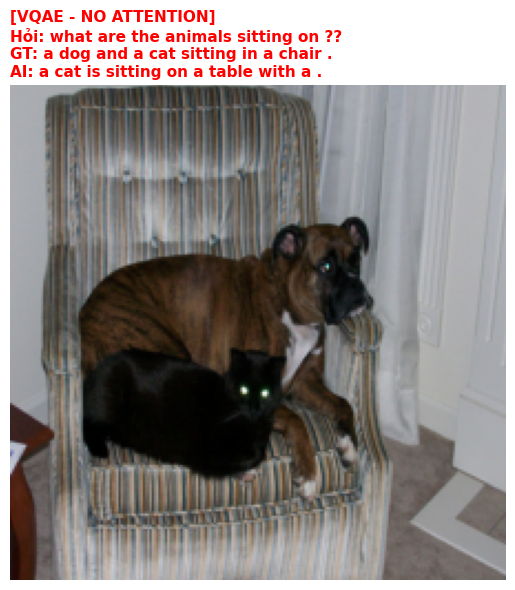

In [18]:
def demo_vqae_noattention(model, dataset, vocab, index=None, max_len=20):
    model.eval()
    if index is None: index = random.randint(0, len(dataset) - 1)

    img_tensor, q_tensor, e_tensor = dataset[index]
    img_input = img_tensor.unsqueeze(0).to(device)
    q_input = q_tensor.unsqueeze(0).to(device)

    def get_word(idx):
        try: return vocab.lookup_token(idx)
        except: return '<unk>'

    with torch.no_grad():
        # Đảm bảo TẮT MỚM BÀI: teacher_forcing_ratio=0.0
        logits = model(img_input, q_input, explanation_input=None, max_gen_len=max_len, sos_idx=vocab['<sos>'], teacher_forcing_ratio=0.0)
        pred_indices = logits.argmax(dim=-1).squeeze(0).tolist()

        pred_words = []
        for idx in pred_indices:
            if idx == vocab['<eos>']: break
            pred_words.append(get_word(idx))

        pred_sentence = " ".join(pred_words)
        if not pred_sentence.strip(): pred_sentence = "<rỗng>"

    # Xử lý text để in ra
    q_text = " ".join([get_word(idx) for idx in q_tensor.tolist() if get_word(idx) not in ['<pad>', '<sos>', '<eos>']])
    true_ans = " ".join([get_word(idx) for idx in e_tensor.tolist() if get_word(idx) not in ['<pad>', '<sos>', '<eos>']])

    # Khôi phục ảnh
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip((np.array([0.229, 0.224, 0.225]) * img_np + np.array([0.485, 0.456, 0.406])), 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    color = 'blue' if pred_sentence == true_ans else 'red'
    plt.title(f"[VQAE - NO ATTENTION]\nHỏi: {q_text}?\nGT: {true_ans}\nAI: {pred_sentence}",
              fontsize=11, color=color, fontweight='bold', loc='left')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Chạy thử
if vocab:
    demo_vqae_noattention(model, val_loader.dataset, vocab)

In [19]:
# Cài đặt các thư viện hỗ trợ tính toán BLEU, ROUGE và CIDEr
!pip install nltk rouge-score pycocoevalcap

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.1 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=71462fba15b206475a4e661509cec8aff423f98880f0ac052ee7bd6d4728b5e8
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


### Giới thiệu các chỉ số đánh giá (Evaluation Metrics)
Chúng tôi sử dụng các chỉ số tiêu chuẩn để định lượng chất lượng ngôn ngữ của các câu giải thích được tạo ra:
- **BLEU (1-4):** Đo lường tỷ lệ khớp n-gram giữa kết quả dự đoán và nhãn gốc.
- **ROUGE-L:** Tập trung vào các dãy từ liên tiếp dài nhất để đánh giá độ mạch lạc của câu.
- **CIDEr:** Tính toán độ tương đồng về mặt ngữ nghĩa bằng cách gán trọng số cho các từ mang tính mô tả cao thông qua TF-IDF.
### Đánh giá mô hình cơ sở (No Attention)
Sử dụng hàm `evaluate_advanced_metrics` để đo lường hiệu năng của mô hình không tích hợp cơ chế Attention trên tập dữ liệu validation (`val_loader`). Kết quả thu được sẽ cung cấp cái nhìn khách quan về khả năng sinh văn bản của kiến trúc cơ bản này trước khi so sánh với các mô hình cải tiến.

In [20]:
import torch
import nltk
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider

# Tải bộ công cụ tách từ của nltk (chạy 1 lần)
nltk.download('punkt')

def evaluate_advanced_metrics(model, dataloader, device, vocab, max_len=20):
    """
    Hàm đánh giá mô hình Seq2Seq bằng các metrics: BLEU (1-4), ROUGE-L và CIDEr.
    """
    model.eval()

    # Từ điển lưu trữ câu Dự đoán và câu Thực tế (định dạng chuẩn cho thư viện CIDEr)
    predictions = {}
    references = {}

    # Khởi tạo công cụ tính ROUGE và BLEU Smoothing
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    smoothie = SmoothingFunction().method4

    bleu1, bleu2, bleu3, bleu4 = 0, 0, 0, 0
    rouge_l_score = 0

    pad_idx = vocab['<pad>']
    sos_idx = vocab['<sos>']
    eos_idx = vocab['<eos>']

    sample_id = 0

    with torch.no_grad():
        # SỬA LỖI 1: Trích xuất imgs, questions, explanations (thay vì answers)
        for imgs, questions, explanations in tqdm(dataloader, desc="Đang đánh giá BLEU/ROUGE/CIDEr"):
            imgs, questions = imgs.to(device), questions.to(device)
            answers = explanations.cpu().numpy()

            # SỬA LỖI 2: Dùng tham số 'explanation_input' cho khớp với mô hình VQA-E
            logits = model(imgs, questions, explanation_input=None, max_gen_len=max_len, sos_idx=sos_idx, teacher_forcing_ratio=0.0)

            # Nếu mô hình trả về (logits, attn_weights) thay vì chỉ logits (cho Attention model)
            if isinstance(logits, tuple): logits = logits[0]

            pred_ids = logits.argmax(dim=-1).cpu().numpy()

            # 2. Xử lý từng mẫu trong Batch
            for i in range(len(imgs)):
                # Lọc bỏ pad, sos, eos khỏi câu dự đoán
                pred_words = []
                for token_id in pred_ids[i]:
                    if token_id == eos_idx: break
                    if token_id not in [pad_idx, sos_idx]:
                        pred_words.append(vocab.lookup_token(token_id))
                pred_str = " ".join(pred_words)
                if not pred_str.strip(): pred_str = "<rỗng>"

                # Lọc bỏ pad, sos, eos khỏi câu nhãn thực tế
                target_words = []
                for token_id in answers[i]:
                    if token_id == eos_idx: break
                    if token_id not in [pad_idx, sos_idx]:
                        target_words.append(vocab.lookup_token(token_id))
                target_str = " ".join(target_words)

                # Lưu vào bộ nhớ cho CIDEr
                predictions[sample_id] = [pred_str]
                references[sample_id] = [target_str]

                # Tính BLEU (Mức câu)
                bleu1 += sentence_bleu([target_words], pred_words, weights=(1, 0, 0, 0), smoothing_function=smoothie)
                bleu2 += sentence_bleu([target_words], pred_words, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
                bleu3 += sentence_bleu([target_words], pred_words, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
                bleu4 += sentence_bleu([target_words], pred_words, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

                # Tính ROUGE-L
                rouge_l_score += scorer.score(target_str, pred_str)['rougeL'].fmeasure

                sample_id += 1

    num_samples = len(predictions)

    # 3. Tính CIDEr (Mức toàn bộ tập Validation)
    cider_scorer = Cider()
    cider_score, _ = cider_scorer.compute_score(references, predictions)

    # 4. Tổng hợp kết quả
    metrics = {
        "BLEU-1": bleu1 / num_samples,
        "BLEU-2": bleu2 / num_samples,
        "BLEU-3": bleu3 / num_samples,
        "BLEU-4": bleu4 / num_samples,
        "ROUGE-L": rouge_l_score / num_samples,
        "CIDEr": cider_score
    }

    print("\n" + "="*40)
    print(" KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH VQA-E (SEQ2SEQ)")
    print("="*40)
    for k, v in metrics.items():
        print(f" > {k:8}: {v:.4f}")
    print("="*40)

    return metrics

# THỰC THI (Hãy đảm bảo đã load model tốt nhất trước khi chạy)
metrics = evaluate_advanced_metrics(model, val_loader, device, vocab)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
Đang đánh giá BLEU/ROUGE/CIDEr: 100%|██████████| 47/47 [00:26<00:00,  1.79it/s]



 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH VQA-E (SEQ2SEQ)
 > BLEU-1  : 0.2922
 > BLEU-2  : 0.1254
 > BLEU-3  : 0.0734
 > BLEU-4  : 0.0465
 > ROUGE-L : 0.2711
 > CIDEr   : 0.2849
